# ch216 — Backpropagation Intuition

Backpropagation is the chain rule *(ch215)* applied to a computation graph in reverse. It is not a new idea — it is a systematic way to accumulate gradients through nested compositions.

Every deep learning framework implements this algorithm internally. Understanding it means you understand how neural networks learn.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Minimal scalar backprop engine ──────────────────────────────────────────
# We represent each value as a node that stores: value, gradient, and backward fn

class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f"Value({self.data:.4f}, grad={self.grad:.4f})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, exp):
        out = Value(self.data ** exp, (self,), f'**{exp}')
        def _backward():
            self.grad += exp * (self.data ** (exp - 1)) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0, self.data), (self,), 'ReLU')
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # Topological sort
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

print("Value class ready")


Value class ready


## Forward and Backward Pass Through a Simple Network

Consider a single neuron: `output = relu(w*x + b)`. We'll trace both passes.

In [2]:
# Single neuron: out = relu(w*x + b)
# True relationship: y = 2x + 1

x = Value(2.0)   # input
w = Value(0.5)   # weight (to learn)
b = Value(0.3)   # bias   (to learn)
target = 5.0     # true output: 2*2+1=5

# Forward pass
z = w * x + b
out = z.relu()
loss = (out + Value(-target)) ** 2  # MSE loss

print(f"Forward: z={z.data:.3f}, out={out.data:.3f}, loss={loss.data:.3f}")

# Backward pass
loss.backward()
print(f"Gradients: dL/dw={w.grad:.4f}, dL/db={b.grad:.4f}")
print(f"  (Positive grads -> decrease w,b to reduce loss)")


Forward: z=1.300, out=1.300, loss=13.690
Gradients: dL/dw=-14.8000, dL/db=-7.4000
  (Positive grads -> decrease w,b to reduce loss)


## Visualising Gradient Flow Through Layers

In a deep network, gradients flow backwards through every layer. The chain rule multiplies at each junction.

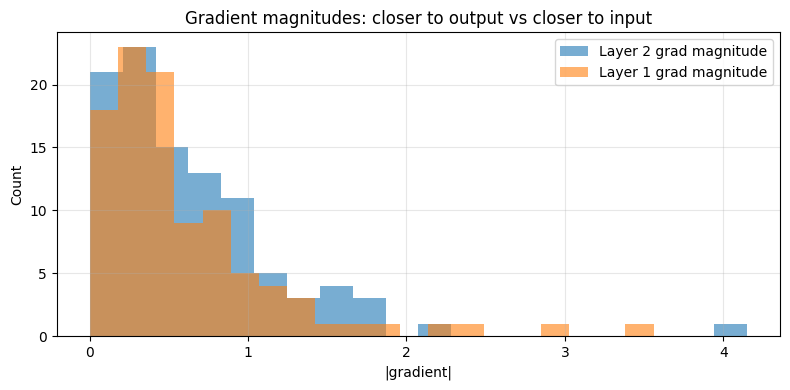

Mean |grad| L2: 0.6291
Mean |grad| L1: 0.5963


In [3]:
# Two-layer network: L = ((w2 * relu(w1*x + b1)) - target)^2
# Trace gradient magnitudes through layers

np.random.seed(42)
n_neurons = 5  # neurons per layer
x_val = 1.5

# Simulate forward pass values and backward gradients
grad_magnitudes_layer1 = []
grad_magnitudes_layer2 = []

for trial in range(100):
    w1 = np.random.randn(n_neurons) * 0.5
    b1 = np.zeros(n_neurons)
    w2 = np.random.randn(n_neurons) * 0.5
    target = 1.0

    # Forward
    h = np.maximum(0, w1 * x_val + b1)  # relu
    out = np.dot(w2, h)
    loss = (out - target) ** 2

    # Backward (manual for this structure)
    dL_dout = 2 * (out - target)
    dL_dw2 = dL_dout * h
    dL_dh = dL_dout * w2
    dL_dz = dL_dh * (h > 0)    # relu gate
    dL_dw1 = dL_dz * x_val

    grad_magnitudes_layer2.append(np.mean(np.abs(dL_dw2)))
    grad_magnitudes_layer1.append(np.mean(np.abs(dL_dw1)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(grad_magnitudes_layer2, bins=20, alpha=0.6, label='Layer 2 grad magnitude')
ax.hist(grad_magnitudes_layer1, bins=20, alpha=0.6, label='Layer 1 grad magnitude')
ax.set_xlabel('|gradient|'); ax.set_ylabel('Count')
ax.set_title('Gradient magnitudes: closer to output vs closer to input')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ch216_gradients.png', dpi=100); plt.show()
print(f"Mean |grad| L2: {np.mean(grad_magnitudes_layer2):.4f}")
print(f"Mean |grad| L1: {np.mean(grad_magnitudes_layer1):.4f}")


## The Vanishing Gradient Problem

When gradients flow through many layers and each local derivative is < 1, the product shrinks exponentially. This makes early layers learn very slowly. It was a major obstacle in deep learning until ReLU activations and careful initialisation were adopted.

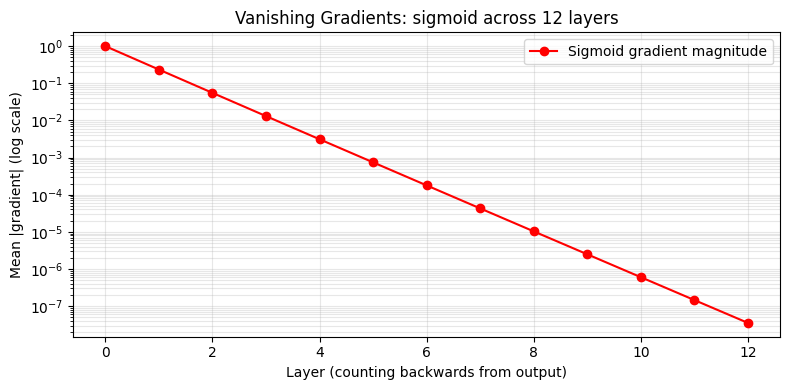

Gradient at layer 0: 1.0000
Gradient at layer 12: 3.53e-08  (0.0000% of original)


In [4]:
# Demonstrate vanishing gradients with sigmoid activations
def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_deriv(x): s = sigmoid(x); return s * (1 - s)  # max 0.25

n_layers = 12
x_in = np.random.randn(32)  # batch of inputs
preactivations = np.random.randn(32) * 0.5  # typical preactivation values

grad = np.ones(32)  # start from output
grad_norms = [np.mean(np.abs(grad))]

for _ in range(n_layers):
    local_grad = sigmoid_deriv(preactivations)  # each element <= 0.25
    grad = grad * local_grad
    grad_norms.append(np.mean(np.abs(grad)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(grad_norms, 'o-', color='red', label='Sigmoid gradient magnitude')
ax.set_xlabel('Layer (counting backwards from output)')
ax.set_ylabel('Mean |gradient| (log scale)')
ax.set_title('Vanishing Gradients: sigmoid across 12 layers')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('ch216_vanishing.png', dpi=100); plt.show()
print(f"Gradient at layer 0: {grad_norms[0]:.4f}")
print(f"Gradient at layer 12: {grad_norms[-1]:.2e}  ({grad_norms[-1]/grad_norms[0]*100:.4f}% of original)")


## Summary

| Concept | Key Idea |
|---|---|
| Forward pass | Compute output, cache intermediate values |
| Backward pass | Apply chain rule in reverse topological order |
| Local gradient | Derivative of each op w.r.t. its inputs |
| Vanishing gradients | Repeated multiplication of small numbers shrinks signal |

**Forward reference:** ch228 — Project: Gradient Descent Visualizer applies this to train a small network. ch227 — Gradient-Based Learning connects the gradient signal to actual parameter updates.